In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# Configuration for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Benchmark des Modèles de Transfert Learning

Comparaison des modèles DinoV2, BEATs, Dasheng et EfficientNet sur les embeddings avec Random Forest

## 1. Chargement des données depuis les fichiers de résultats

In [32]:
# Define paths
base_path = Path('../../Results/Random_Forest')
models = {
    'DinoV2': 'RF_DinoV2',
    'BEATs': 'RF_BEATs',
    'Dasheng': 'RF_dasheng',
    'EfficientNet': 'RF_efficientnet'
}

# Function to extract metrics from summary file
def extract_metrics_from_summary(file_path):
    """Extract Balanced Accuracy and Macro F1 Score from summary file"""
    metrics = {}
    with open(file_path, 'r') as f:
        content = f.read()
        
    # Extract Macro F1 Score
    f1_match = re.search(r'Macro F1 Score\s*:\s*([\d.]+)', content)
    if f1_match:
        metrics['F1 Score Macro'] = float(f1_match.group(1))
    
    # Extract Balanced Accuracy
    ba_match = re.search(r'Balanced Accuracy\s*:\s*([\d.]+)', content)
    if ba_match:
        metrics['Balanced Accuracy'] = float(ba_match.group(1))
    
    # Extract number of features (embedding dimension)
    features_match = re.search(r'Number of features[^:]*:\s*([\d]+)', content)
    if features_match:
        metrics['Embedding Dimension'] = int(features_match.group(1))
    
    return metrics

# Load all metrics
all_metrics = {}
for model_name, model_folder in models.items():
    summary_path = base_path / model_folder / 'summary_RF_1.txt'
    all_metrics[model_name] = extract_metrics_from_summary(summary_path)
    print(f"{model_name}: {all_metrics[model_name]}")

DinoV2: {'F1 Score Macro': 0.7003, 'Balanced Accuracy': 0.6954, 'Embedding Dimension': 1024}
BEATs: {'F1 Score Macro': 0.7759, 'Balanced Accuracy': 0.7477, 'Embedding Dimension': 768}
Dasheng: {'F1 Score Macro': 0.7721, 'Balanced Accuracy': 0.7527, 'Embedding Dimension': 768}
EfficientNet: {'F1 Score Macro': 0.7126, 'Balanced Accuracy': 0.6981, 'Embedding Dimension': 1280}


## 2. Ajout des données de temps de calcul et dimensions

In [33]:
# Add timing and dimension data
timing_data = {
    'DinoV2': {
        'Embedding Time (s)': 748,  # 12 minutes 28 seconds
        'RF Training Time (s)': 831,  # 13 minutes 51 seconds
    },
    'BEATs': {
        'Embedding Time (s)': 278,  # 4 minutes 38 seconds
        'RF Training Time (s)': 322,  # 5 minutes 22 seconds
    },
    'Dasheng': {
        'Embedding Time (s)': 180,  # 3 minutes
        'RF Training Time (s)': 576,  # 9 minutes 36 seconds
    },
    'EfficientNet': {
        'Embedding Time (s)': 644,  # 10 minutes 44 seconds
        'RF Training Time (s)': 1565,  # 26 minutes 05 seconds
    }
}

# Merge timing data with metrics
for model_name, timing in timing_data.items():
    all_metrics[model_name].update(timing)

# Create DataFrame for easier manipulation
df_metrics = pd.DataFrame(all_metrics).T
print("\nAll Metrics:")
print(df_metrics)
print("\nData types:")
print(df_metrics.dtypes)


All Metrics:
              F1 Score Macro  Balanced Accuracy  Embedding Dimension  \
DinoV2                0.7003             0.6954               1024.0   
BEATs                 0.7759             0.7477                768.0   
Dasheng               0.7721             0.7527                768.0   
EfficientNet          0.7126             0.6981               1280.0   

              Embedding Time (s)  RF Training Time (s)  
DinoV2                     748.0                 831.0  
BEATs                      278.0                 322.0  
Dasheng                    180.0                 576.0  
EfficientNet               644.0                1565.0  

Data types:
F1 Score Macro          float64
Balanced Accuracy       float64
Embedding Dimension     float64
Embedding Time (s)      float64
RF Training Time (s)    float64
dtype: object


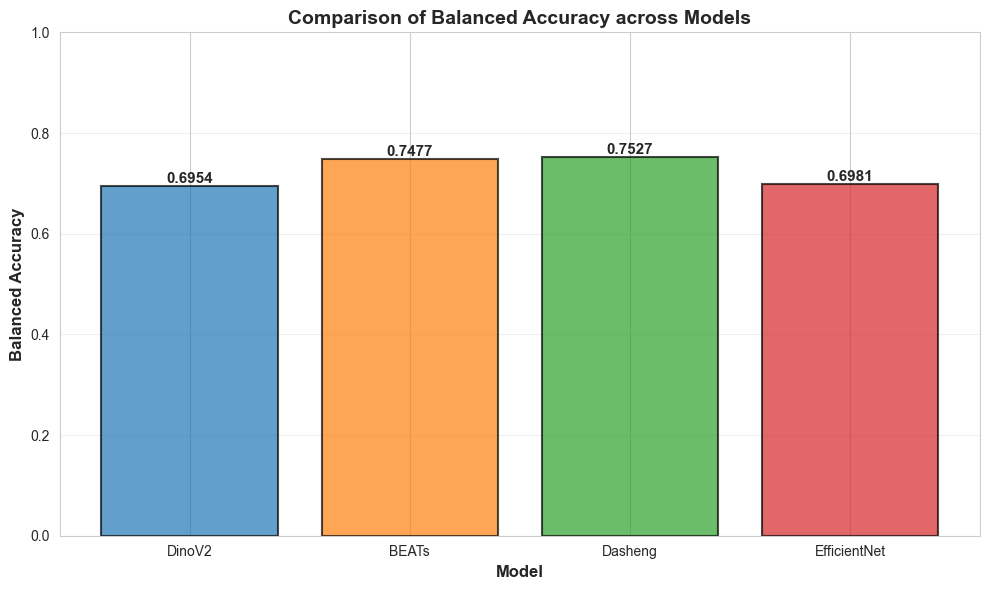

Best Balanced Accuracy: Dasheng (0.7527)


In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

models_list = list(df_metrics.index)
ba_values = df_metrics['Balanced Accuracy'].values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

bars = ax.bar(models_list, ba_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Balanced Accuracy', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Balanced Accuracy across Models', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('balanced_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best Balanced Accuracy: {df_metrics['Balanced Accuracy'].idxmax()} ({df_metrics['Balanced Accuracy'].max():.4f})")

## 5. Comparaison du F1 Score Macro

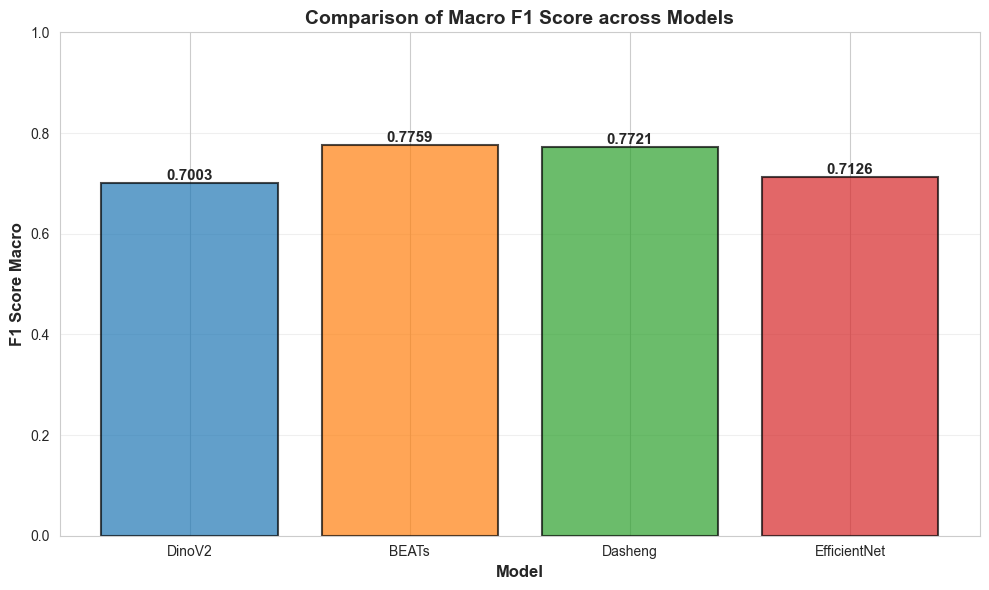

Best F1 Score Macro: BEATs (0.7759)


In [35]:
fig, ax = plt.subplots(figsize=(10, 6))

f1_values = df_metrics['F1 Score Macro'].values

bars = ax.bar(models_list, f1_values, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('F1 Score Macro', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Comparison of Macro F1 Score across Models', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('f1_score_macro_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best F1 Score Macro: {df_metrics['F1 Score Macro'].idxmax()} ({df_metrics['F1 Score Macro'].max():.4f})")

## 6. Comparaison des Matrices de Confusion

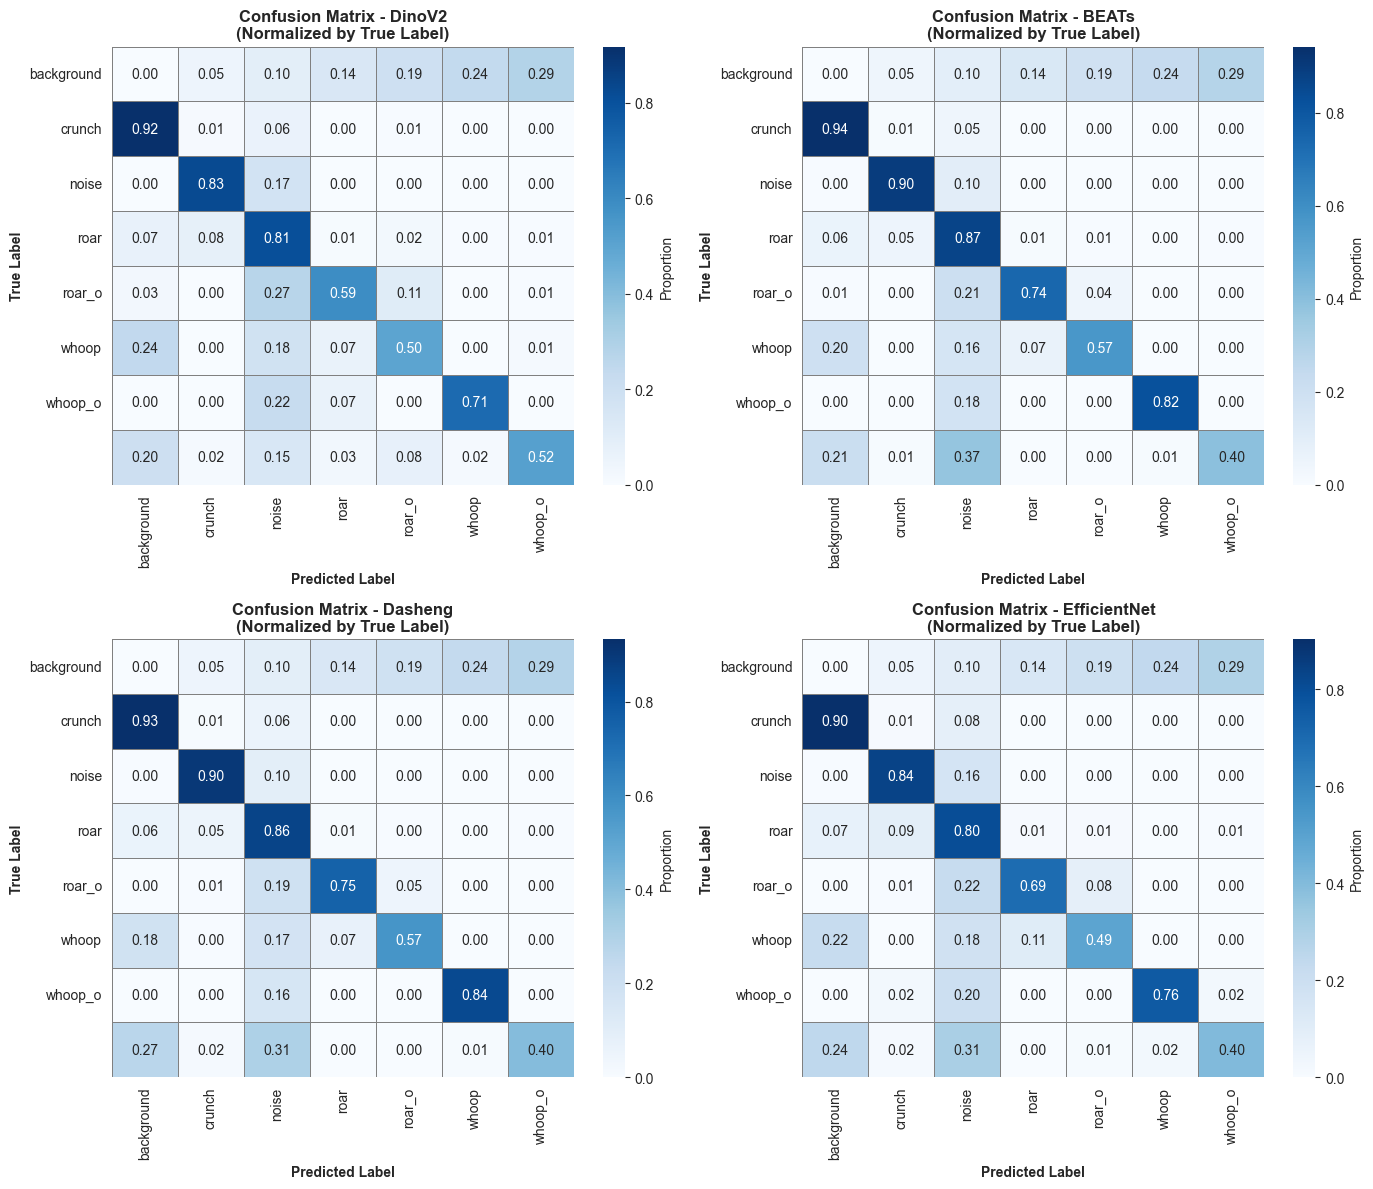

In [36]:
class_names = ['background', 'crunch', 'noise', 'roar', 'roar_o', 'whoop', 'whoop_o']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, cm) in enumerate(confusion_matrices.items()):
    cm_array = cm.values.astype(float)
    
    # Normalize by row (true label)
    cm_normalized = cm_array / cm_array.sum(axis=1, keepdims=True)
    
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar_kws={'label': 'Proportion'},
                linewidths=0.5, linecolor='gray')
    
    axes[idx].set_title(f'Confusion Matrix - {model_name}\n(Normalized by True Label)', 
                       fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('True Label', fontweight='bold')
    axes[idx].set_xlabel('Predicted Label', fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Temps de Calcul des Embeddings

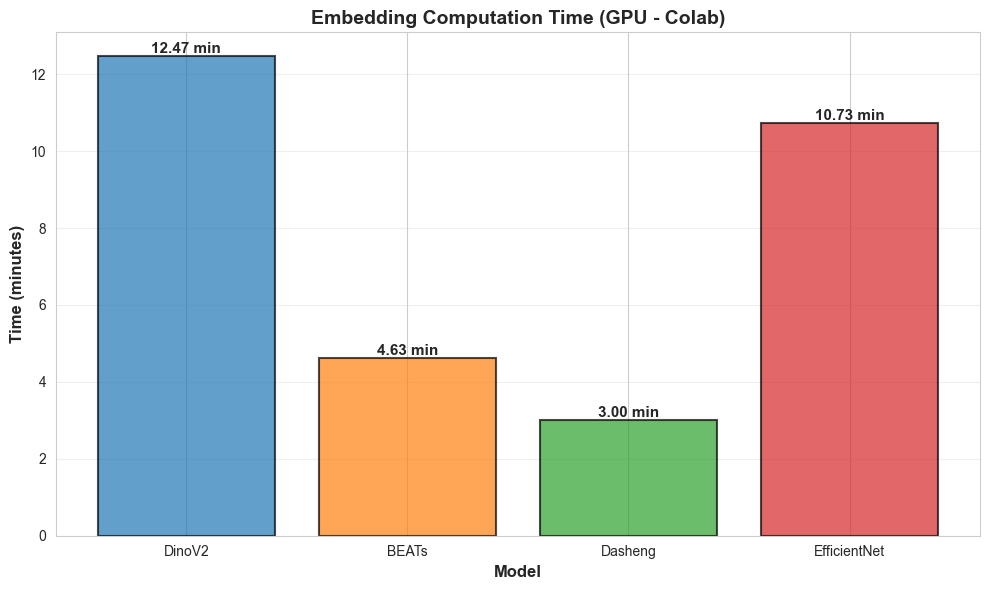

Fastest: Dasheng (3.00 min)
Slowest: DinoV2 (12.47 min)


In [37]:
fig, ax = plt.subplots(figsize=(10, 6))

embedding_times = df_metrics['Embedding Time (s)'].values / 60  # Convert to minutes

bars = ax.bar(models_list, embedding_times, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f} min',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Time (minutes)', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Embedding Computation Time (GPU - Colab)', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('embedding_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fastest: {df_metrics['Embedding Time (s)'].idxmin()} ({df_metrics['Embedding Time (s)'].min()/60:.2f} min)")
print(f"Slowest: {df_metrics['Embedding Time (s)'].idxmax()} ({df_metrics['Embedding Time (s)'].max()/60:.2f} min)")

## 8. Temps d'Entraînement du Random Forest

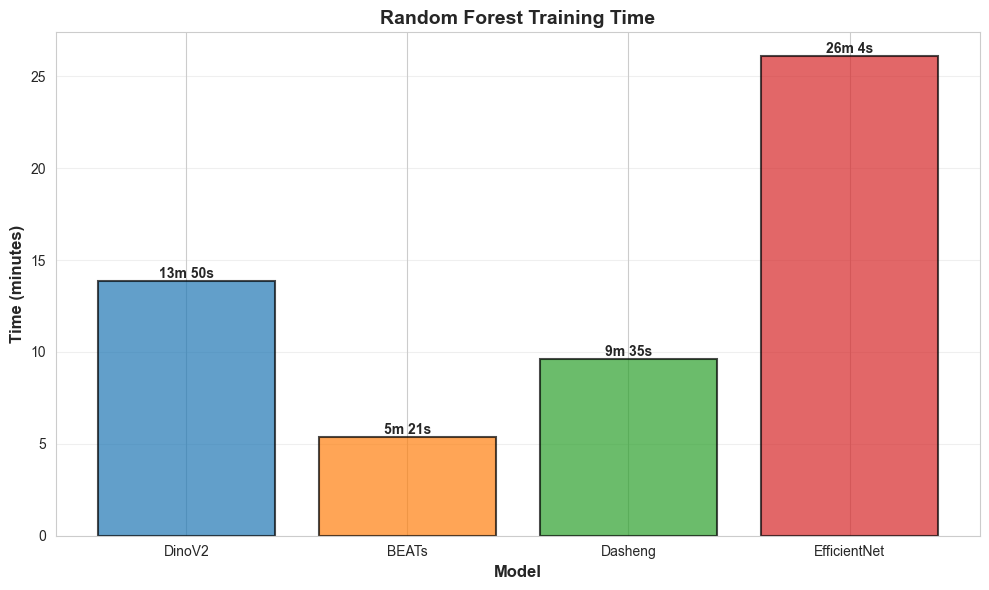

Fastest: BEATs (5.37 min)
Slowest: EfficientNet (26.08 min)


In [38]:
fig, ax = plt.subplots(figsize=(10, 6))

rf_times = df_metrics['RF Training Time (s)'].values / 60  # Convert to minutes

bars = ax.bar(models_list, rf_times, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    minutes = int(height)
    seconds = int((height - minutes) * 60)
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{minutes}m {seconds}s',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Time (minutes)', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Random Forest Training Time', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('rf_training_time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Fastest: {df_metrics['RF Training Time (s)'].idxmin()} ({df_metrics['RF Training Time (s)'].min()/60:.2f} min)")
print(f"Slowest: {df_metrics['RF Training Time (s)'].idxmax()} ({df_metrics['RF Training Time (s)'].max()/60:.2f} min)")

## 9. Dimension des Vecteurs d'Embedding

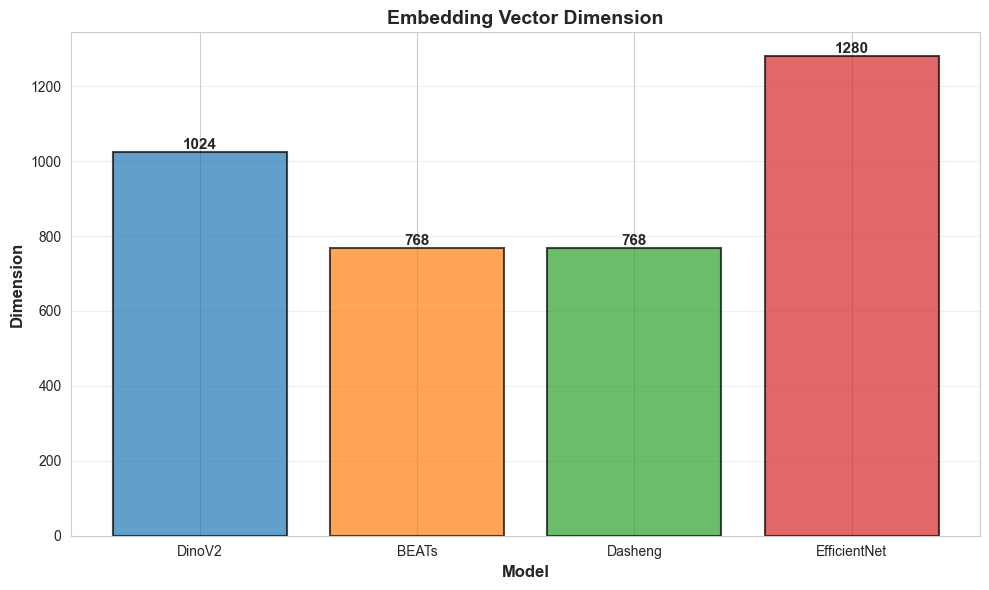

Smallest: BEATs (768.0 dimensions)
Largest: EfficientNet (1280.0 dimensions)


In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

dimensions = df_metrics['Embedding Dimension'].values

bars = ax.bar(models_list, dimensions, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylabel('Dimension', fontsize=12, fontweight='bold')
ax.set_xlabel('Model', fontsize=12, fontweight='bold')
ax.set_title('Embedding Vector Dimension', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('embedding_dimension_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Smallest: {df_metrics['Embedding Dimension'].idxmin()} ({df_metrics['Embedding Dimension'].min()} dimensions)")
print(f"Largest: {df_metrics['Embedding Dimension'].idxmax()} ({df_metrics['Embedding Dimension'].max()} dimensions)")

## 10. Synthèse - Tableau Récapitulatif

In [40]:
# Create summary DataFrame with formatted data
df_summary = df_metrics.copy()

# Format numerical columns
df_summary['Balanced Accuracy'] = df_summary['Balanced Accuracy'].apply(lambda x: f'{x:.4f}')
df_summary['F1 Score Macro'] = df_summary['F1 Score Macro'].apply(lambda x: f'{x:.4f}')
df_summary['Embedding Time (min)'] = (df_summary['Embedding Time (s)'] / 60).apply(lambda x: f'{x:.2f}')
df_summary['RF Training Time (min)'] = (df_summary['RF Training Time (s)'] / 60).apply(lambda x: f'{x:.2f}')
df_summary['Embedding Dimension'] = df_summary['Embedding Dimension'].astype(int)

# Select and reorder columns for display
df_display = df_summary[['Balanced Accuracy', 'F1 Score Macro', 'Embedding Dimension',
                          'Embedding Time (min)', 'RF Training Time (min)']].copy()

df_display.columns = ['Balanced Accuracy', 'F1 Score Macro', 'Embedding Dim',
                      'Embed Time (min)', 'RF Time (min)']

print("\n" + "="*80)
print("SUMMARY TABLE - MODEL COMPARISON")
print("="*80)
print(df_display.to_string())
print("="*80)


SUMMARY TABLE - MODEL COMPARISON
             Balanced Accuracy F1 Score Macro  Embedding Dim Embed Time (min) RF Time (min)
DinoV2                  0.6954         0.7003           1024            12.47         13.85
BEATs                   0.7477         0.7759            768             4.63          5.37
Dasheng                 0.7527         0.7721            768             3.00          9.60
EfficientNet            0.6981         0.7126           1280            10.73         26.08


## 11. Analyse des Performances par Classe


Per-Class F1 Score Table
              background  crunch  noise  roar  roar_o  whoop  whoop_o
DinoV2              0.91    0.82   0.82  0.61    0.50   0.69     0.57
BEATs               0.93    0.89   0.87  0.73    0.68   0.82     0.52
Dasheng             0.92    0.88   0.87  0.73    0.69   0.80     0.52
EfficientNet        0.90    0.81   0.81  0.67    0.57   0.72     0.51



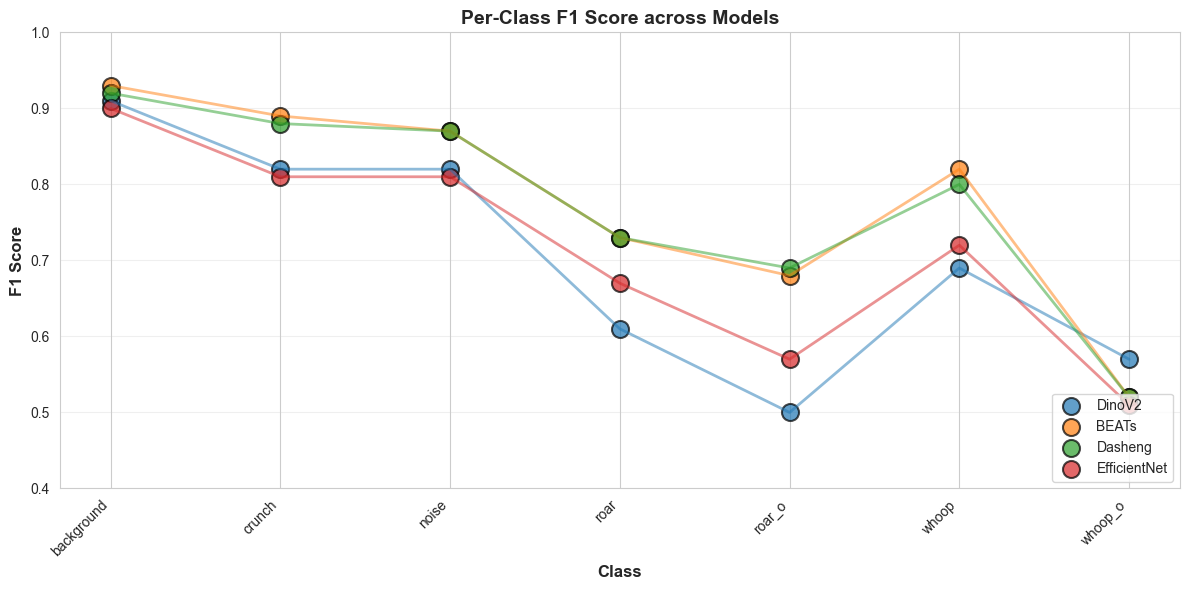

In [41]:
class_names = ['background', 'crunch', 'noise', 'roar', 'roar_o', 'whoop', 'whoop_o']


def extract_class_f1_from_summary(file_path, class_names):
    """Extract per-class F1 scores from a random forest summary file."""
    class_f1 = {}
    pattern = re.compile(r'^\s*(' + '|'.join(map(re.escape, class_names)) + r')\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+(\d+)\s*$')
    in_classification_report = False

    with open(file_path, 'r', encoding='utf-8') as f:
        for raw_line in f:
            line = raw_line.rstrip('\n')
            if line.strip() == 'Classification report:':
                in_classification_report = True
                continue

            if not in_classification_report:
                continue

            match = pattern.match(line)
            if match:
                class_name = match.group(1)
                class_f1[class_name] = float(match.group(4))
            elif line.strip().startswith(('accuracy', 'macro avg', 'weighted avg')):
                break

    return class_f1


# Load per-class F1 scores for all models
class_f1_all = {}
for model_name, model_folder in models.items():
    summary_path = base_path / model_folder / 'summary_RF_1.txt'
    class_f1_all[model_name] = extract_class_f1_from_summary(summary_path, class_names)


# Create DataFrame in model order and class order
df_class_f1 = pd.DataFrame(class_f1_all).T.reindex(index=models_list, columns=class_names)

# Display the table
print("\n" + "="*90)
print("Per-Class F1 Score Table")
print("="*90)
print(df_class_f1.to_string())
print("="*90 + "\n")

# Visualize per-class F1 performance as scatter plot with lines
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(class_names))
colors_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, model_name in enumerate(models_list):
    f1_values = df_class_f1.loc[model_name].values
    ax.plot(x, f1_values, color=colors_list[i], alpha=0.5, linewidth=2)
    ax.scatter(x, f1_values, label=model_name, s=150, alpha=0.7, color=colors_list[i], edgecolors='black', linewidth=1.5)

ax.set_ylabel('F1 Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_title('Per-Class F1 Score across Models', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.4, 1])

plt.tight_layout()
plt.savefig('per_class_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Comparaison Multi-Critères (Radar Chart)

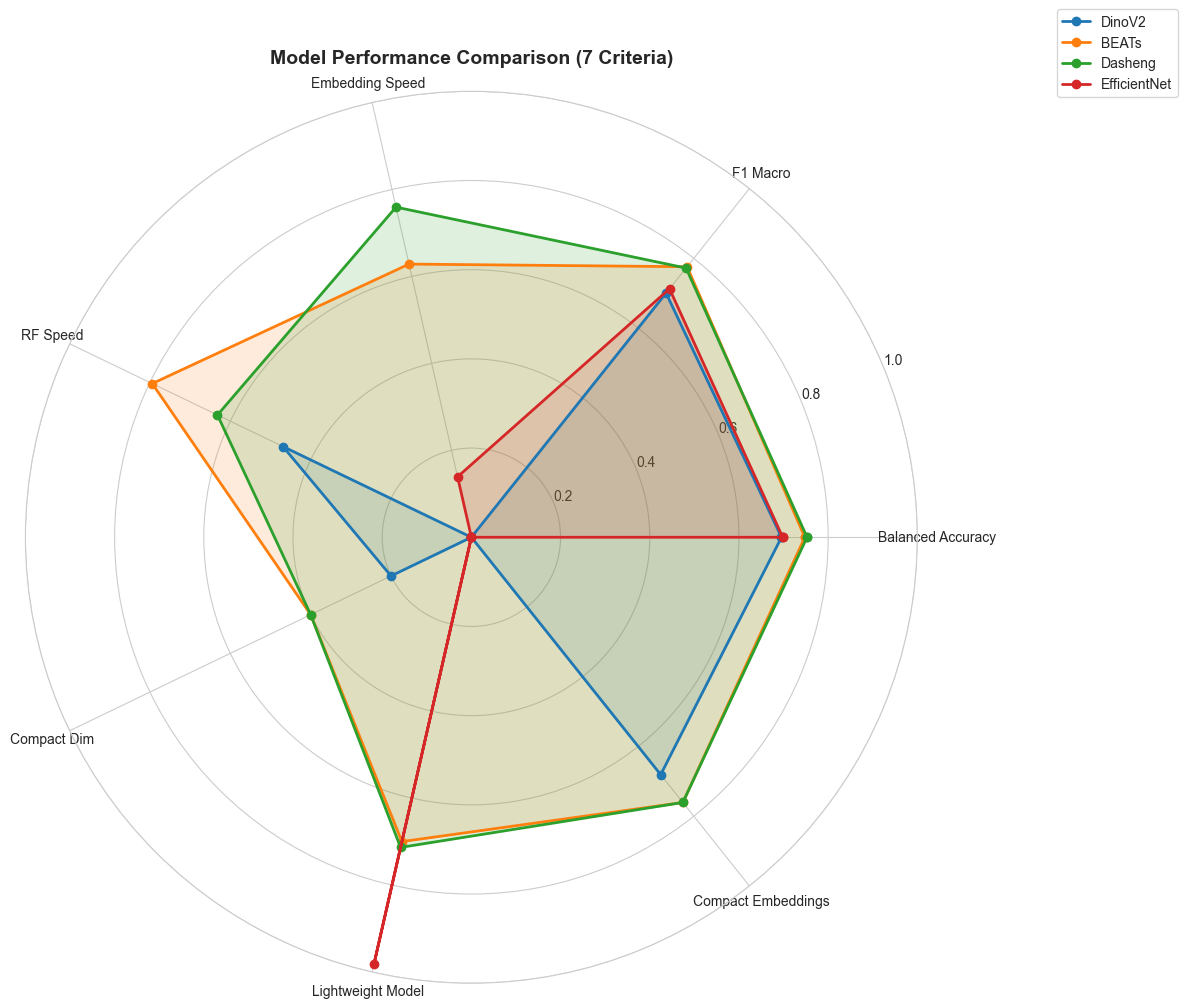

In [42]:
# Add model parameters and embeddings file size data
model_params = {'DinoV2': 300, 'BEATs': 90, 'Dasheng': 86, 'EfficientNet': 5.27}
embeddings_size = {'DinoV2': 60, 'BEATs': 45, 'Dasheng': 45, 'EfficientNet': 188}

df_metrics['Model Parameters (M)'] = pd.Series(model_params)
df_metrics['Embeddings File Size (MB)'] = pd.Series(embeddings_size)

# Normalize metrics for radar chart (0-1 scale)
df_normalized = df_metrics.copy()

# Normalize timing (lower is better, so we invert: 1 - (value / max))
df_normalized['Embedding Time (s)'] = 1 - (df_metrics['Embedding Time (s)'] / df_metrics['Embedding Time (s)'].max())
df_normalized['RF Training Time (s)'] = 1 - (df_metrics['RF Training Time (s)'] / df_metrics['RF Training Time (s)'].max())

# Normalize dimension (lower is better)
df_normalized['Embedding Dimension'] = 1 - (df_metrics['Embedding Dimension'] / df_metrics['Embedding Dimension'].max())

# Normalize model parameters (lower is better)
df_normalized['Model Parameters (M)'] = 1 - (df_metrics['Model Parameters (M)'] / df_metrics['Model Parameters (M)'].max())

# Normalize embeddings file size (lower is better)
df_normalized['Embeddings File Size (MB)'] = 1 - (df_metrics['Embeddings File Size (MB)'] / df_metrics['Embeddings File Size (MB)'].max())

# Select metrics for radar chart
metrics_for_radar = ['Balanced Accuracy', 'F1 Score Macro', 'Embedding Time (s)',
                     'RF Training Time (s)', 'Embedding Dimension', 'Model Parameters (M)',
                     'Embeddings File Size (MB)']
radar_labels = ['Balanced Accuracy', 'F1 Macro', 'Embedding Speed', 'RF Speed', 'Compact Dim',
                'Lightweight Model', 'Compact Embeddings']

# Create radar chart
angles = np.linspace(0, 2 * np.pi, len(radar_labels), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

fig, ax = plt.subplots(figsize=(12, 12), subplot_kw=dict(projection='polar'))

colors_radar = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, model_name in enumerate(models_list):
    values = [df_normalized.loc[model_name, metric] for metric in metrics_for_radar]
    values += values[:1]  # Complete the circle
    
    ax.plot(angles, values, 'o-', linewidth=2, label=model_name, color=colors_radar[idx])
    ax.fill(angles, values, alpha=0.15, color=colors_radar[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_title('Model Performance Comparison (7 Criteria)', 
            fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()